# Model ablation

## ablate FM

In [ ]:
%%bash
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_no_fm.pt" \
            --no-fm \
            --graph-type "go+pert+ppi" \
            --skip-vae-pretrain
    done
done

## randomize graph

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

splits=(1 2 3)


# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_rgraph.pt" \
            --randomize-graph \
            --graph-type "go+pert+ppi" \
            --skip-vae-pretrain
    done
done

## both

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_rgraph_no_fm.pt" \
            --randomize-graph \
            --no-fm \
            --graph-type "go+pert+ppi" \
            --skip-vae-pretrain
    done
done

## Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from gfm.helpers import combine_results

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8

In [ ]:
datasets = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
results = []
test_results_list = []

for dataset in datasets:
    results_dict = {
        'GFM': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+gwps+ppi_gat.csv" for s in [1, 2, 3]],
        'GFM (w/o FM)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_no_fm.csv" for s in [1, 2, 3]],
        'GFM (rand. graph)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph.csv" for s in [1, 2, 3]],
        'GFM (rand. graph + w/o FM)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_no_fm.csv" for s in [1, 2, 3]],
        'Perturb train': [f"../data/pert_train/{dataset}/results_test_{s}.csv" for s in [1, 2, 3]]
    }
    res_dict = combine_results(results_dict, baseline_model="Perturb train", return_test_results=True)
    result_combined = res_dict['combined_results']
    result_combined['dataset'] = dataset
    results.append(result_combined)

    test_results = res_dict['test_results']
    test_results['dataset'] = dataset
    test_results_list.append(test_results)
    
results_all = pd.concat(results, ignore_index=True)
test_results_all = pd.concat(test_results_list, ignore_index=True)

In [ ]:
datasets = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
results = []

for dataset in datasets:
    results_dict = {
        'GFM': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+gwps+ppi_gat.csv" for s in [1, 2, 3]],
        'GFM (w/o FM)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_no_fm.csv" for s in [1, 2, 3]],
        'GFM (rand. graph)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph.csv" for s in [1, 2, 3]],
        'GFM (rand. graph + w/o FM)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_no_fm.csv" for s in [1, 2, 3]],
        'Perturb train': [f"../data/pert_train/{dataset}/results_test_{s}.csv" for s in [1, 2, 3]]
    }
    res_dict = combine_results(
        results_dict, 
        baseline_model="Perturb train", 
        return_test_results=True,
        aggregate_by_split=True)
    aggr_res = res_dict['aggregated_results']
    aggr_res['dataset'] = dataset
    results.append(aggr_res)
    
results_all = pd.concat(results, ignore_index=True)

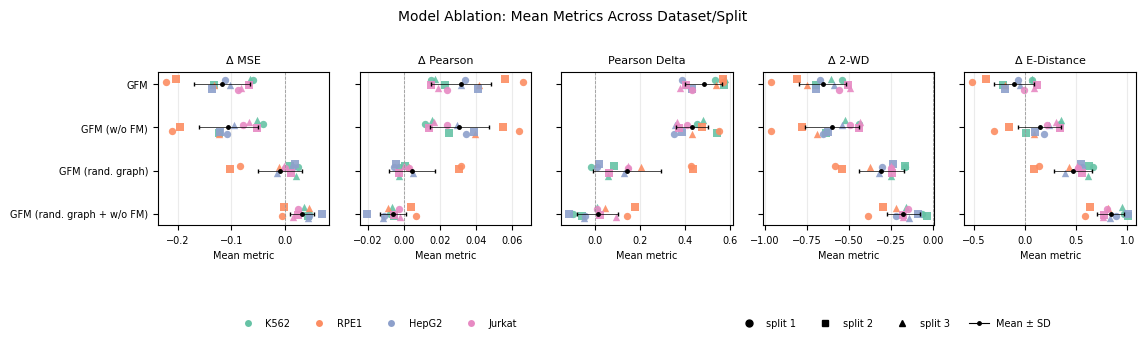

In [ ]:
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

summary = (
    results_all
    .groupby(['model'])
    .agg(
        mean_mse_mean=('mse_mean', 'mean'),
        mean_pearson_mean=('pearson_mean', 'mean'),
        mean_pearson_delta_mean=('pearson_delta_mean', 'mean'),
        mean_w2d_mean=('w2d_mean', 'mean'),
        mean_e_distance_mean=('e_distance_mean', 'mean'),
        sd_mse_mean=('mse_mean', 'std'),
        sd_pearson_mean=('pearson_mean', 'std'),
        sd_pearson_delta_mean=('pearson_delta_mean', 'std'),
        sd_w2d_mean=('w2d_mean', 'std'),
        sd_e_distance_mean=('e_distance_mean', 'std'),
    )
    .reset_index()
)

metrics = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']
metric_labels = {
    'mse': 'Δ MSE',
    'pearson': 'Δ Pearson',
    'pearson_delta': 'Pearson Delta',
    'w2d': 'Δ 2-WD',
    'e_distance': 'Δ E-Distance',
}

plot_df = results_all.copy()
plot_df['split'] = plot_df['split'].astype(str)

model_order = [
    m for m in [
        'GFM (rand. graph + w/o FM)',
        'GFM (rand. graph)',
        'GFM (w/o FM)',
        'GFM',
    ] if m in plot_df['model'].unique()
 ]
if not model_order:
    model_order = sorted(plot_df['model'].unique())

dataset_order = [
    d for d in [
        'norman_single',
        'replogle_k562',
        'replogle_rpe1',
        'nadig_hepg2',
        'nadig_jurkat',
    ] if d in plot_df['dataset'].unique()
 ]
if not dataset_order:
    dataset_order = sorted(plot_df['dataset'].unique())

palette = dict(zip(dataset_order, sns.color_palette('Set2', len(dataset_order))))
split_order = sorted(plot_df['split'].unique(), key=int)
marker_cycle = ['o', 's', '^', 'D', 'P', 'X']
split_markers = {s: marker_cycle[i % len(marker_cycle)] for i, s in enumerate(split_order)}

fig, axes = plt.subplots(1, len(metrics), figsize=(2.3 * len(metrics), 2.8), sharey=True)
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    x_col = f'{metric}_mean'
    x_sum_col = f'mean_{metric}_mean'
    x_sd_col = f'sd_{metric}_mean'
    this_df = plot_df[['model', 'dataset', 'split', x_col]].dropna().copy()

    y_map = {model: idx for idx, model in enumerate(model_order)}
    this_df = this_df[this_df['model'].isin(model_order)]
    this_df[x_col] = pd.to_numeric(this_df[x_col], errors='coerce')
    this_df['y_base'] = this_df['model'].map(y_map).astype(float)

    rng = np.random.default_rng(42)
    this_df['y'] = this_df['y_base'] + rng.uniform(-0.17, 0.17, len(this_df))

    for _, row in this_df.iterrows():
        color = palette.get(row['dataset'], 'gray')
        marker = split_markers.get(row['split'], 'o')

        ax.scatter(
            row[x_col],
            row['y'],
            color=color,
            marker=marker,
            s=28,
            linewidth=0,
            alpha=0.9,
            zorder=2,
        )
    
    ax.errorbar(
        summary[x_sum_col],
        [y_map.get(model, np.nan) for model in summary['model']],
        xerr=summary[x_sd_col],
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=0.5,
        capsize=1.5,
        markersize=2.5,
        zorder=4,
    )

    ax.axvline(0, color='0.6', linestyle='--', linewidth=0.6)
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_title(metric_labels.get(metric, metric), fontsize=8)
    ax.set_xlabel('Mean metric', fontsize=7)

    ax.set_yticks(range(len(model_order)))

axes[0].set_yticklabels(model_order, fontsize=7)
axes[0].tick_params(axis='y', labelleft=True, left=True)
for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)

dataset_map = {
    'replogle_k562': 'K562',
    'replogle_rpe1': 'RPE1',
    'nadig_hepg2': 'HepG2',
    'nadig_jurkat': 'Jurkat',
}

dataset_handles = [
    Line2D([0], [0], marker='o', linestyle='', color=palette[d], markeredgewidth=0, markersize=5, label=dataset_map.get(d, d))
    for d in dataset_order
]
split_handles = [
    Line2D([0], [0], marker=split_markers[s], linestyle='', color='black', markersize=5, label=f'split {s}')
    for s in split_order
]
mean_handle = [
    Line2D([0], [0], marker='o', linestyle='-', color='black', markersize=2.5, linewidth=0.8, label='Mean ± SD')
]

fig.legend(handles=dataset_handles, title=None, loc='lower center', bbox_to_anchor=(0.33, -0.14), ncol=4, frameon=False, fontsize=7, title_fontsize=8)
fig.legend(handles=split_handles+mean_handle, title=None, loc='lower center', bbox_to_anchor=(0.78, -0.14), ncol=len(split_handles) + 1, frameon=False, fontsize=7, title_fontsize=8)

fig.suptitle('Model Ablation: Mean Metrics Across Dataset/Split', y=1.03, fontsize=10)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.savefig("../data/final_plots/ablation_module_metrics_summary.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Graph ablation

## GO+Pert

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat' 'norman_combo')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
    "../data/preprocessed_norman_combo.h5ad"
)
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_go+gwps_gat.pt" \
            --graph-type "go+pert" \
            --save-times \
    done
done

## GO+PPI

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat' 'norman_combo')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
    "../data/preprocessed_norman_combo.h5ad"
)
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_go+ppi_gat.pt" \
            --graph-type "go+ppi" \
            --save-times \
    done
done

## GO

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat' 'norman_combo')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
    "../data/preprocessed_norman_combo.h5ad"
)
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm.pt" \
            --graph-type "go" \
            --save-times \
    done
done

## Results

In [ ]:
datasets = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
results = []
test_results_list = []

for dataset in datasets:
    results_dict = {
        'GFM (GO+Pert+PPI)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+gwps+ppi_gat.csv" for s in [1, 2, 3]],
        'GFM (GO+PPI)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+ppi_gat.csv" for s in [1, 2, 3]],
        'GFM (GO+Pert)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+gwps_gat.csv" for s in [1, 2, 3]],
        'GFM (GO)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm.csv" for s in [1, 2, 3]],
        'Perturb train': [f"../data/pert_train/{dataset}/results_test_{s}.csv" for s in [1, 2, 3]]
    }
    res_dict = combine_results(
        results_dict, 
        baseline_model="Perturb train", 
        return_test_results=True,
        aggregate_by_split=True,
        reference_model='GFM (GO+Pert+PPI)')
    aggr_res = res_dict['aggregated_results']
    aggr_res['dataset'] = dataset
    results.append(aggr_res)

    test_results = res_dict['test_results']
    test_results['dataset'] = dataset
    test_results_list.append(test_results)
    
results_all = pd.concat(results, ignore_index=True)
test_results_all = pd.concat(test_results_list, ignore_index=True)

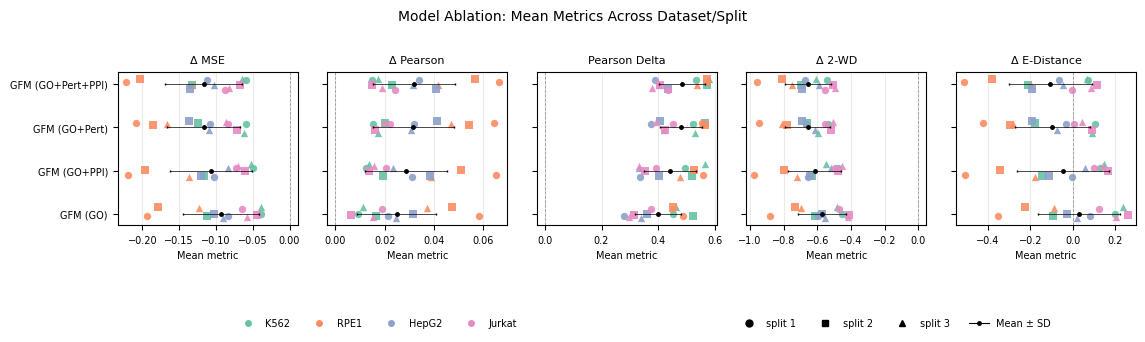

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D

summary = (
    results_all
    .groupby(['model'])
    .agg(
        mean_mse_mean=('mse_mean', 'mean'),
        mean_pearson_mean=('pearson_mean', 'mean'),
        mean_pearson_delta_mean=('pearson_delta_mean', 'mean'),
        mean_w2d_mean=('w2d_mean', 'mean'),
        mean_e_distance_mean=('e_distance_mean', 'mean'),
        sd_mse_mean=('mse_mean', 'std'),
        sd_pearson_mean=('pearson_mean', 'std'),
        sd_pearson_delta_mean=('pearson_delta_mean', 'std'),
        sd_w2d_mean=('w2d_mean', 'std'),
        sd_e_distance_mean=('e_distance_mean', 'std'),
    )
    .reset_index()
)

metrics = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']
metric_labels = {
    'mse': 'Δ MSE',
    'pearson': 'Δ Pearson',
    'pearson_delta': 'Pearson Delta',
    'w2d': 'Δ 2-WD',
    'e_distance': 'Δ E-Distance',
}

plot_df = results_all.copy()
plot_df['split'] = plot_df['split'].astype(str)

model_order = [
    m for m in [
        'GFM (GO)',
        'GFM (GO+PPI)',
        'GFM (GO+Pert)',
        'GFM (GO+Pert+PPI)',
        
    ] if m in plot_df['model'].unique()
 ]
if not model_order:
    model_order = sorted(plot_df['model'].unique())

dataset_order = [
    d for d in [
        'norman_single',
        'replogle_k562',
        'replogle_rpe1',
        'nadig_hepg2',
        'nadig_jurkat',
    ] if d in plot_df['dataset'].unique()
 ]
if not dataset_order:
    dataset_order = sorted(plot_df['dataset'].unique())

palette = dict(zip(dataset_order, sns.color_palette('Set2', len(dataset_order))))
split_order = sorted(plot_df['split'].unique(), key=int)
marker_cycle = ['o', 's', '^', 'D', 'P', 'X']
split_markers = {s: marker_cycle[i % len(marker_cycle)] for i, s in enumerate(split_order)}

fig, axes = plt.subplots(1, len(metrics), figsize=(2.3 * len(metrics), 2.8), sharey=True)
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    x_col = f'{metric}_mean'
    x_sum_col = f'mean_{metric}_mean'
    x_sd_col = f'sd_{metric}_mean'
    this_df = plot_df[['model', 'dataset', 'split', x_col]].dropna().copy()

    y_map = {model: idx for idx, model in enumerate(model_order)}
    this_df = this_df[this_df['model'].isin(model_order)]
    this_df[x_col] = pd.to_numeric(this_df[x_col], errors='coerce')
    this_df['y_base'] = this_df['model'].map(y_map).astype(float)

    rng = np.random.default_rng(42)
    this_df['y'] = this_df['y_base'] + rng.uniform(-0.17, 0.17, len(this_df))

    for _, row in this_df.iterrows():
        color = palette.get(row['dataset'], 'gray')
        marker = split_markers.get(row['split'], 'o')

        ax.scatter(
            row[x_col],
            row['y'],
            color=color,
            marker=marker,
            s=28,
            linewidth=0,
            alpha=0.9,
            zorder=2,
        )
    ax.errorbar(
        summary[x_sum_col],
        [y_map.get(model, np.nan) for model in summary['model']],
        xerr=summary[x_sd_col],
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=0.5,
        capsize=1,
        markersize=2.5,
        zorder=4,
    )

    ax.axvline(0, color='0.6', linestyle='--', linewidth=0.6)
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_title(metric_labels.get(metric, metric), fontsize=8)
    ax.set_xlabel('Mean metric', fontsize=7)

    ax.set_yticks(range(len(model_order)))

axes[0].set_yticklabels(model_order, fontsize=7)
axes[0].tick_params(axis='y', labelleft=True, left=True)
for ax in axes[1:]:
    # Do not call set_yticklabels([]) on shared axes; it clears labels for all axes.
    ax.tick_params(axis='y', labelleft=False)

dataset_map = {
    'replogle_k562': 'K562',
    'replogle_rpe1': 'RPE1',
    'nadig_hepg2': 'HepG2',
    'nadig_jurkat': 'Jurkat',
}

dataset_handles = [
    Line2D([0], [0], marker='o', linestyle='', color=palette[d], markeredgewidth=0, markersize=5, label=dataset_map.get(d, d))
    for d in dataset_order
]
split_handles = [
    Line2D([0], [0], marker=split_markers[s], linestyle='', color='black', markersize=5, label=f'split {s}')
    for s in split_order
]
mean_handle = [
    Line2D([0], [0], marker='o', linestyle='-', color='black', markersize=2.5, linewidth=0.8, label='Mean ± SD')
]

fig.legend(handles=dataset_handles, title=None, loc='lower center', bbox_to_anchor=(0.33, -0.14), ncol=4, frameon=False, fontsize=7)
fig.legend(handles=split_handles+mean_handle, title=None, loc='lower center', bbox_to_anchor=(0.78, -0.14), ncol=len(split_handles) + 1, frameon=False, fontsize=7)

fig.suptitle('Model Ablation: Mean Metrics Across Dataset/Split', y=1.03, fontsize=10)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.savefig("../data/final_plots/ablation_graph_metrics_summary.pdf", dpi=300, bbox_inches='tight')
plt.show()